2026-03-15 23:32:16.466756: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-15 23:32:16.633873: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-15 23:32:18.336502: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/dragon99/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/lay

Epoch 1/10


2026-03-15 23:32:25.548535: I external/local_xla/xla/service/service.cc:163] XLA service 0x79bfa4005500 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-15 23:32:25.548567: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-03-15 23:32:25.611365: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-15 23:32:25.818158: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-03-15 23:32:25.877449: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-15 23:32:25.

 48/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1303 - loss: 2.2887

I0000 00:00:1773595951.317381    4361 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.3745 - loss: 1.7189 - val_accuracy: 0.4508 - val_loss: 1.5057
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4793 - loss: 1.4365 - val_accuracy: 0.4972 - val_loss: 1.3940
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5242 - loss: 1.3251 - val_accuracy: 0.5380 - val_loss: 1.2792
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5556 - loss: 1.2433 - val_accuracy: 0.5494 - val_loss: 1.2641
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5780 - loss: 1.1892 - val_accuracy: 0.5816 - val_loss: 1.1840
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5954 - loss: 1.1369 - val_accuracy: 0.5842 - val_loss: 1.1934
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6102 - loss: 1.0925 - val_accuracy: 0.5864 - val_loss: 1.1749
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6261 - loss: 1.0524 - val_accuracy: 0.5910 - val

2026-03-15 23:32:56.418278: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-15 23:32:57.004012: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_114', 16 bytes spill stores, 16 bytes spill loads



313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6168 - loss: 1.0997
Test Accuracy: 0.6168000102043152
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


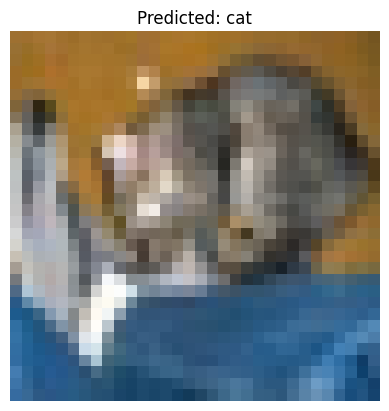

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# Load CIFAR10
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Build LeNet model
model = keras.Sequential([
layers.Conv2D(6,(5,5),activation='relu',input_shape=(32,32,3)),
layers.AveragePooling2D((2,2)),

layers.Conv2D(16,(5,5),activation='relu'),
layers.AveragePooling2D((2,2)),

layers.Flatten(),

layers.Dense(120,activation='relu'),
layers.Dense(84,activation='relu'),
layers.Dense(10,activation='softmax')
])

# Compile
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

# Train
history = model.fit(
X_train,
y_train,
epochs=10,
batch_size=64,
validation_split=0.1
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test,y_test)
print("Test Accuracy:",test_acc)

# Prediction example
pred = model.predict(X_test)
idx = 0
predicted_class = np.argmax(pred[idx])

plt.imshow(X_test[idx])
plt.title("Predicted: "+classes[predicted_class])
plt.axis("off")
plt.show()